# Final Submission: End-to-End Pipeline

**Authors:** Leonel Lourenco, Rana Khan
**Course:** IS392 Section 452
**Institution:** New Jersey Institute of Technology
**Date:** April 2026

## Purpose
This notebook synthesizes all results from the improved classification pipeline (notebook 06) into the final submission narrative. It loads the pre-computed results tables, generates summary visualizations, and answers the research questions with rigorous CV-based numbers.

## Source of Numbers
All metrics in this notebook come from notebook 06's outputs:
- `data/processed/results_comparison.csv` - single 80/20 split with F1-optimal threshold
- `data/processed/cv_results.csv` - **primary source**, 5-fold stratified CV
- `data/processed/tuning_results.csv` - Phase 3 hyperparameter tuning sweep

## Improvement Phases Applied
- **Phase 1**: Imbalance handling (SMOTE tuning, threshold optimization, cross-validation)
- **Phase 2**: Feature engineering (temporal features, interactions, SelectKBest on TF-IDF)
- **Phase 3**: Hyperparameter tuning (GridSearchCV) + SMOTE variant comparison

## Expected Runtime
- Fast: ~30 seconds (loads pre-computed CSVs from notebook 06, no model training)

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
import sys
import joblib
from scipy import sparse

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score)

# SMOTE
from imblearn.over_sampling import SMOTE

# NLP
import spacy
from gensim.models import LdaModel, CoherenceModel
from gensim.corpora import Dictionary
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from collections import Counter
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42
print('Environment configured.')

Environment configured.


## 2. Configuration

In [2]:
# Paths
CSV_INPUT = '../data/raw/usaspending'  # Folder with CSV files or zip
FINAL_OUTPUT = '../data/processed/labeled_contracts.csv'
DOC_TOPIC_PATH = '../data/processed/doc_topic_matrix.parquet'
TFIDF_MATRIX_PATH = '../data/processed/tfidf_matrix.npz'
MODELS_DIR = '../models'
FIGURES_DIR = '../figures'
RESULTS_PATH = '../data/processed/results_comparison.csv'

# Sample size (None = use all, or specify number for sampling)
SAMPLE_CONTRACTS = None

# Thresholds
COST_OVERRUN_THRESHOLD = 0.05
COST_OVERRUN_THRESHOLD_FALLBACK = 0.01
SCHEDULE_DELAY_THRESHOLD = 0

# LDA
TOPIC_COUNTS = [10, 12, 15, 18, 20, 25, 30]
DICT_NO_BELOW = 15
DICT_NO_ABOVE = 0.5

# TF-IDF
TFIDF_MAX_FEATURES = 500

# Training
TEST_SIZE = 0.20
SMOTE_THRESHOLD = 0.10

print('Configuration loaded.')

Configuration loaded.


## 3. Load Improved Results from Notebook 06

Notebook 06 produces three result tables:
- `results_comparison.csv` — Single 80/20 split, F1-optimal threshold (Phase 1B)
- `cv_results.csv` — 5-fold stratified cross-validation (Phase 1C)
- `tuning_results.csv` — GridSearchCV + SMOTE variants (Phase 3)

This notebook synthesizes these into the final submission narrative.

In [3]:
# Load all results from notebook 06
RESULTS_PATH = '../data/processed/results_comparison.csv'
CV_RESULTS_PATH = '../data/processed/cv_results.csv'
TUNING_RESULTS_PATH = '../data/processed/tuning_results.csv'
LABELED_DATA_PATH = '../data/processed/labeled_contracts.csv'

# Load labeled data for dataset summary
print('Loading labeled dataset...')
df = pd.read_csv(LABELED_DATA_PATH)
print(f'Total contracts: {len(df):,}')

# Load improved results
results_df = pd.read_csv(RESULTS_PATH)
cv_df = pd.read_csv(CV_RESULTS_PATH)
tuning_df = pd.read_csv(TUNING_RESULTS_PATH)

print(f'\nSingle-split results: {len(results_df)} rows (16-model grid)')
print(f'5-fold CV results:     {len(cv_df)} rows (16-model grid)')
print(f'Tuning results:        {len(tuning_df)} rows (Phase 3 sweep)')

# Load text feature artifacts (for context)
DOC_TOPIC_PATH = '../data/processed/doc_topic_matrix.parquet'
TFIDF_MATRIX_PATH = '../data/processed/tfidf_matrix.npz'
if Path(DOC_TOPIC_PATH).exists():
    topic_df = pd.read_parquet(DOC_TOPIC_PATH)
    topic_cols = [c for c in topic_df.columns if c.startswith('topic_')]
    print(f'\nLDA topics: {len(topic_cols)} (from {len(topic_df):,} docs)')
if Path(TFIDF_MATRIX_PATH).exists():
    tfidf_matrix = sparse.load_npz(TFIDF_MATRIX_PATH)
    print(f'TF-IDF features: {tfidf_matrix.shape[1]:,}')

Loading labeled dataset...
Total contracts: 45,456

Single-split results: 16 rows (16-model grid)
5-fold CV results:     16 rows (16-model grid)
Tuning results:        7 rows (Phase 3 sweep)



LDA topics: 18 (from 9,357 docs)
TF-IDF features: 500


## 4. Best Model Identification

Identify the best (target, config, algorithm) combinations from the 5-fold CV.

In [4]:
# Identify best models per target from 5-fold CV
best_models = {}
print('=' * 70)
print('BEST MODELS BY 5-FOLD CV F1')
print('=' * 70)

for target in ['over_budget', 'late']:
    target_cv = cv_df[cv_df['target'] == target].sort_values('f1_mean', ascending=False)
    best = target_cv.iloc[0]
    best_models[target] = {
        'config': best['config'],
        'algorithm': best['algorithm'],
        'f1_mean': best['f1_mean'],
        'f1_std': best['f1_std'],
        'auc_mean': best['auc_mean'],
        'auc_std': best['auc_std'],
        'threshold_mean': best['threshold_mean']
    }
    print(f'\n{target}:')
    print(f'  Best:       Config {best.config} ({best.algorithm})')
    print(f'  F1 (CV):    {best.f1_mean:.3f} ± {best.f1_std:.3f}')
    print(f'  AUC (CV):   {best.auc_mean:.3f} ± {best.auc_std:.3f}')
    print(f'  Threshold:  {best.threshold_mean:.3f} (F1-optimal)')
    print(f'\n  Top 3 by F1:')
    for _, row in target_cv.head(3).iterrows():
        print(f'    Config {row.config} ({row.algorithm:20s}) F1={row.f1_mean:.3f}±0.{int(row.f1_std*1000):03d}')

BEST MODELS BY 5-FOLD CV F1

over_budget:
  Best:       Config D (LogisticRegression)
  F1 (CV):    0.358 ± 0.010
  AUC (CV):   0.775 ± 0.003
  Threshold:  0.481 (F1-optimal)

  Top 3 by F1:
    Config D (LogisticRegression  ) F1=0.358±0.010
    Config D (RandomForest        ) F1=0.353±0.006
    Config A (LogisticRegression  ) F1=0.334±0.009

late:
  Best:       Config D (RandomForest)
  F1 (CV):    0.881 ± 0.003
  AUC (CV):   0.890 ± 0.003
  Threshold:  0.417 (F1-optimal)

  Top 3 by F1:
    Config D (RandomForest        ) F1=0.881±0.003
    Config A (RandomForest        ) F1=0.879±0.003
    Config A (LogisticRegression  ) F1=0.869±0.002


## 5. Visualize Performance

Comparison plots across configs, targets, and algorithms.

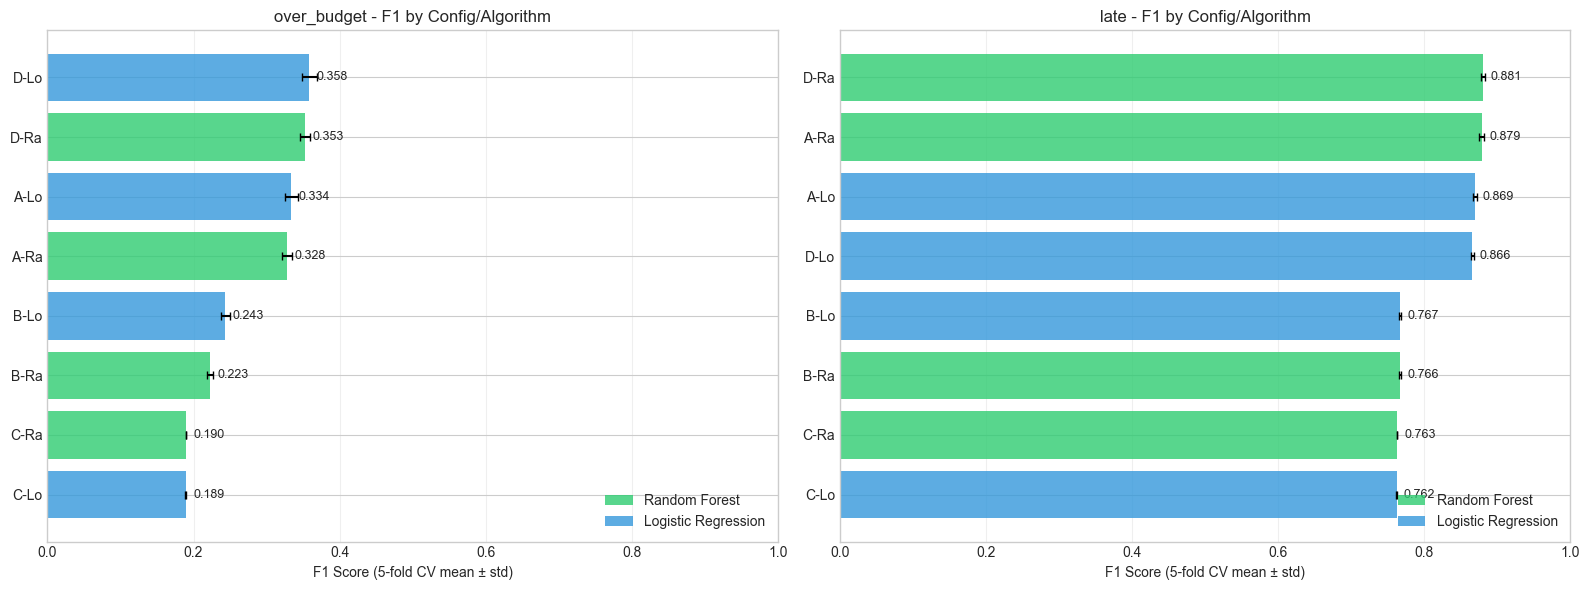

Saved: figures/cv_f1_comparison.png


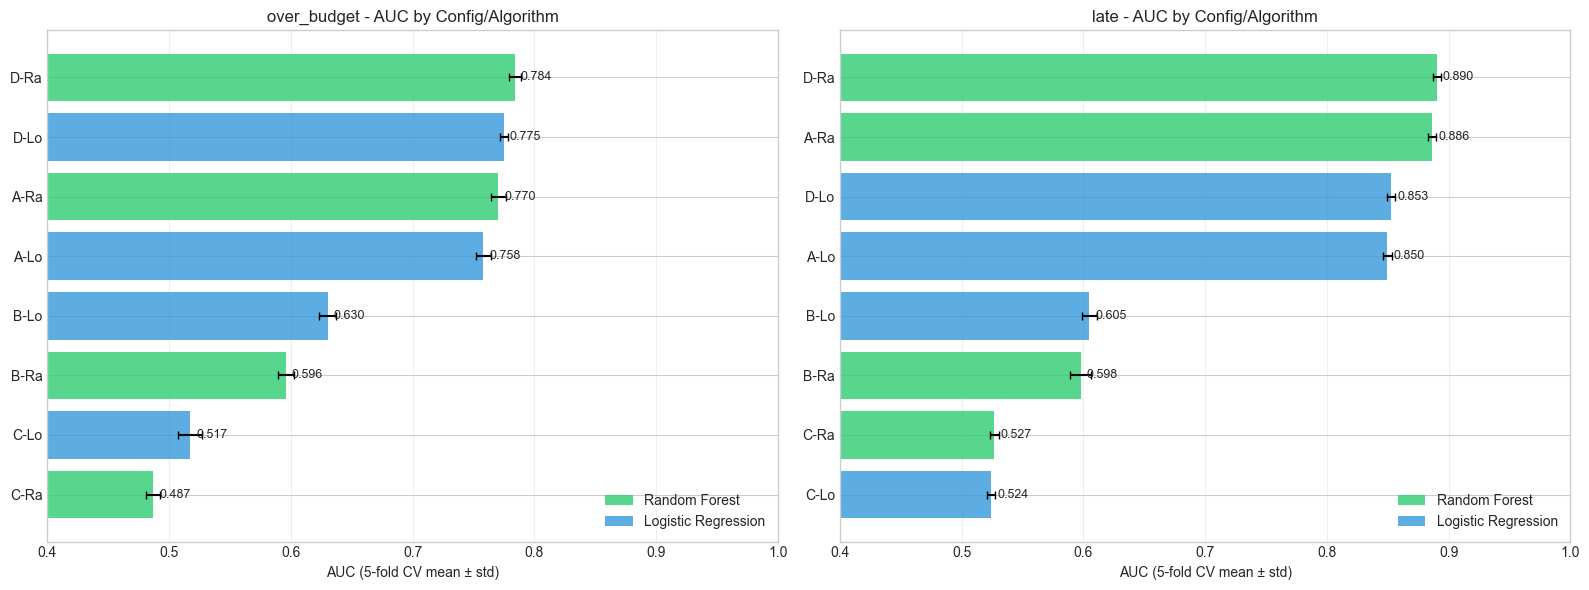

Saved: figures/cv_auc_comparison.png


In [5]:
# Plot 5-fold CV F1 comparison across all configs and algorithms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, target in enumerate(['over_budget', 'late']):
    ax = axes[ax_idx]
    target_cv = cv_df[cv_df['target'] == target].copy()
    target_cv['label'] = target_cv['config'] + '-' + target_cv['algorithm'].str[:2]
    target_cv = target_cv.sort_values('f1_mean')

    colors = ['#2ecc71' if alg == 'RandomForest' else '#3498db'
              for alg in target_cv['algorithm']]

    bars = ax.barh(target_cv['label'], target_cv['f1_mean'],
                   xerr=target_cv['f1_std'], color=colors, alpha=0.8,
                   error_kw=dict(elinewidth=1.5, capsize=3))
    ax.set_xlabel('F1 Score (5-fold CV mean ± std)')
    ax.set_title(f'{target} - F1 by Config/Algorithm')
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3, axis='x')

    # Annotate bars
    for bar, val in zip(bars, target_cv['f1_mean']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ecc71', alpha=0.8, label='Random Forest'),
                       Patch(facecolor='#3498db', alpha=0.8, label='Logistic Regression')]
    ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/cv_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cv_f1_comparison.png')

# AUC comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_idx, target in enumerate(['over_budget', 'late']):
    ax = axes[ax_idx]
    target_cv = cv_df[cv_df['target'] == target].copy()
    target_cv['label'] = target_cv['config'] + '-' + target_cv['algorithm'].str[:2]
    target_cv = target_cv.sort_values('auc_mean')

    colors = ['#2ecc71' if alg == 'RandomForest' else '#3498db'
              for alg in target_cv['algorithm']]

    bars = ax.barh(target_cv['label'], target_cv['auc_mean'],
                   xerr=target_cv['auc_std'], color=colors, alpha=0.8,
                   error_kw=dict(elinewidth=1.5, capsize=3))
    ax.set_xlabel('AUC (5-fold CV mean ± std)')
    ax.set_title(f'{target} - AUC by Config/Algorithm')
    ax.set_xlim(0.4, 1)
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, target_cv['auc_mean']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    legend_elements = [Patch(facecolor='#2ecc71', alpha=0.8, label='Random Forest'),
                       Patch(facecolor='#3498db', alpha=0.8, label='Logistic Regression')]
    ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/cv_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cv_auc_comparison.png')

## 6. Phase 3 Tuning Results: Before/After Comparison

PHASE 3: HYPERPARAMETER TUNING + SMOTE VARIANT COMPARISON

All runs target over_budget (priority: imbalanced, harder to predict)

--- Phase 3C: SMOTE variant comparison (Random Forest, Config A) ---
  smote_variant       f1      auc  best_threshold
          SMOTE 0.340643 0.777167        0.293856
BorderlineSMOTE 0.346126 0.777974        0.288758
         ADASYN 0.344325 0.775299        0.342309

--- Phase 3A: GridSearchCV LR (Config A) ---
  Best params: {'C': 10.0, 'class_weight': {0: 1, 1: 3}, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  F1: 0.334, AUC: 0.759

--- Phase 3B: GridSearchCV RF (Config A) ---
  Best params: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
  F1: 0.342, AUC: 0.775

--- Final Eval: Tuned models on Config D ---
                 algorithm       f1      auc  best_threshold
LogisticRegression (tuned) 0.349877 0.771582        0.585656
      RandomForest (tuned) 0.346106 0.784284        0.312251


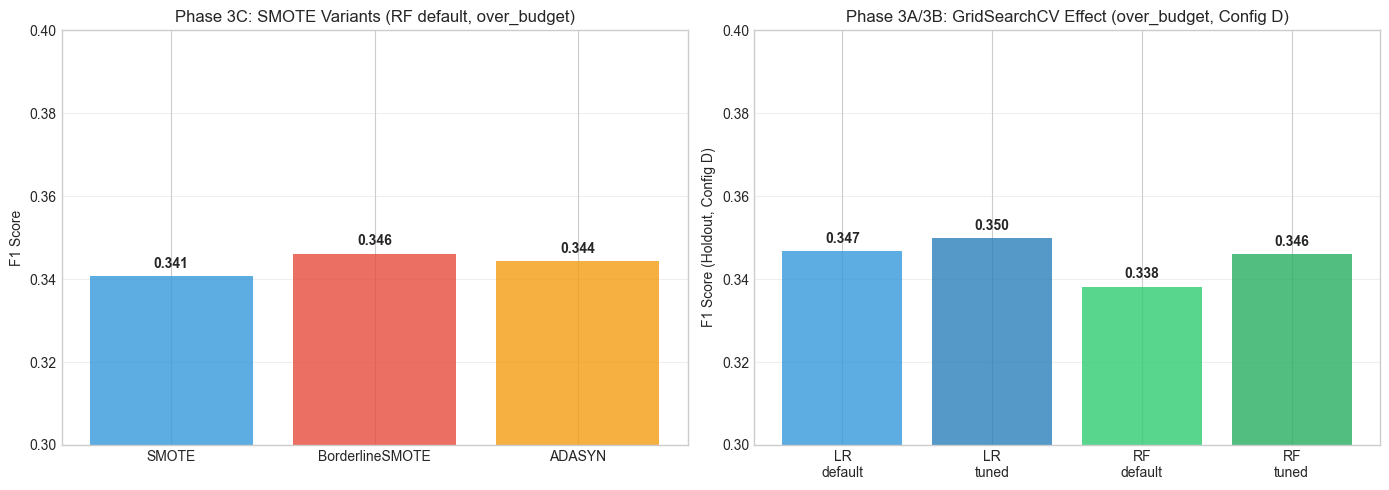


Saved: figures/phase3_tuning_comparison.png


In [6]:
# Phase 3 tuning: before/after comparison
print('=' * 70)
print('PHASE 3: HYPERPARAMETER TUNING + SMOTE VARIANT COMPARISON')
print('=' * 70)
print('\nAll runs target over_budget (priority: imbalanced, harder to predict)')

# SMOTE variants
print('\n--- Phase 3C: SMOTE variant comparison (Random Forest, Config A) ---')
smote_3c = tuning_df[tuning_df['phase'] == '3C_smote_variant']
print(smote_3c[['smote_variant', 'f1', 'auc', 'best_threshold']].to_string(index=False))

# GridSearchCV
print('\n--- Phase 3A: GridSearchCV LR (Config A) ---')
lr_3a = tuning_df[tuning_df['phase'] == '3A_gridsearch_lr'].iloc[0]
print(f'  Best params: {lr_3a.params}')
print(f'  F1: {lr_3a.f1:.3f}, AUC: {lr_3a.auc:.3f}')

print('\n--- Phase 3B: GridSearchCV RF (Config A) ---')
rf_3b = tuning_df[tuning_df['phase'] == '3B_gridsearch_rf'].iloc[0]
print(f'  Best params: {rf_3b.params}')
print(f'  F1: {rf_3b.f1:.3f}, AUC: {rf_3b.auc:.3f}')

# Final eval on Config D
print('\n--- Final Eval: Tuned models on Config D ---')
final_eval = tuning_df[tuning_df['phase'] == 'final_eval']
print(final_eval[['algorithm', 'f1', 'auc', 'best_threshold']].to_string(index=False))

# Visual: SMOTE variants comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(smote_3c['smote_variant'], smote_3c['f1'],
       color=['#3498db', '#e74c3c', '#f39c12'], alpha=0.8)
ax.set_ylabel('F1 Score')
ax.set_title('Phase 3C: SMOTE Variants (RF default, over_budget)')
ax.set_ylim(0.3, 0.4)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(smote_3c['f1']):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

ax = axes[1]
labels = ['LR\ndefault', 'LR\ntuned', 'RF\ndefault', 'RF\ntuned']
# Get corresponding F1 values from results_df (default) and tuning_df (tuned)
ob_results = results_df[(results_df.target == 'over_budget') & (results_df.config == 'D')]
default_lr_f1 = ob_results[ob_results.algorithm == 'LogisticRegression']['f1'].iloc[0]
default_rf_f1 = ob_results[ob_results.algorithm == 'RandomForest']['f1'].iloc[0]
tuned_lr_f1 = final_eval[final_eval.algorithm == 'LogisticRegression (tuned)']['f1'].iloc[0]
tuned_rf_f1 = final_eval[final_eval.algorithm == 'RandomForest (tuned)']['f1'].iloc[0]
values = [default_lr_f1, tuned_lr_f1, default_rf_f1, tuned_rf_f1]
colors = ['#3498db', '#2980b9', '#2ecc71', '#27ae60']
ax.bar(labels, values, color=colors, alpha=0.8)
ax.set_ylabel('F1 Score (Holdout, Config D)')
ax.set_title('Phase 3A/3B: GridSearchCV Effect (over_budget, Config D)')
ax.set_ylim(0.3, 0.4)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/phase3_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: figures/phase3_tuning_comparison.png')

## 7. Research Questions: Final Answers

Numbers come from `cv_results.csv` (5-fold stratified CV) for robust point estimates.

In [7]:
# Answer research questions with improved numbers
print('=' * 70)
print('RESEARCH QUESTIONS - FINAL ANSWERS')
print('=' * 70)

# Best per target
ob_best = best_models['over_budget']
late_best = best_models['late']

# Q1: Can NLP + structured features predict outcomes?
print('\nQ1: Can text features (NLP) + structured features predict contract outcomes?')
print(f'  Late deliveries:    AUC = {late_best["auc_mean"]:.3f} ± {late_best["auc_std"]:.3f} (Config {late_best["config"]}, {late_best["algorithm"]})')
print(f'  Cost overruns:      AUC = {ob_best["auc_mean"]:.3f} ± {ob_best["auc_std"]:.3f} (Config {ob_best["config"]}, {ob_best["algorithm"]})')
print(f'  Verdict: YES for late (high signal); WEAKER for over_budget (more inherent noise)')

# Q2: Which feature set is best?
print('\nQ2: Which feature configuration performs best?')
print('  Config A: structured only')
print('  Config B: TF-IDF only')
print('  Config C: LDA topics only')
print('  Config D: combined (structured + LDA + TF-IDF)')
for target in ['over_budget', 'late']:
    target_cv = cv_df[cv_df['target'] == target]
    print(f'\n  {target}:')
    for config in ['A', 'B', 'C', 'D']:
        config_cv = target_cv[target_cv.config == config]
        if not config_cv.empty:
            best_alg = config_cv.sort_values('f1_mean', ascending=False).iloc[0]
            print(f'    Config {config}: F1={best_alg.f1_mean:.3f}±{best_alg.f1_std:.3f}, AUC={best_alg.auc_mean:.3f}±{best_alg.auc_std:.3f} ({best_alg.algorithm})')

# Q3: Do text features add value over structured-only?
print('\nQ3: Do text features (LDA + TF-IDF) add value over structured-only?')
for target in ['over_budget', 'late']:
    target_cv = cv_df[cv_df['target'] == target]
    A = target_cv[target_cv.config == 'A'].sort_values('f1_mean', ascending=False).iloc[0]
    D = target_cv[target_cv.config == 'D'].sort_values('f1_mean', ascending=False).iloc[0]
    delta_f1 = D.f1_mean - A.f1_mean
    delta_auc = D.auc_mean - A.auc_mean
    print(f'\n  {target}:')
    print(f'    Config A (structured): F1={A.f1_mean:.3f}, AUC={A.auc_mean:.3f}')
    print(f'    Config D (all):        F1={D.f1_mean:.3f}, AUC={D.auc_mean:.3f}')
    print(f'    Lift from text:        ΔF1={delta_f1:+.3f}, ΔAUC={delta_auc:+.3f}')

# Q4: How much did the improvements help?
print('\nQ4: How much did the Phase 1-3 improvements help?')
baseline = {
    'over_budget': {'f1': 0.336, 'auc': 0.779},
    'late': {'f1': 0.869, 'auc': 0.840}
}
for target in ['over_budget', 'late']:
    best = best_models[target]
    bl = baseline[target]
    f1_lift = (best['f1_mean'] - bl['f1']) / bl['f1'] * 100
    auc_lift = (best['auc_mean'] - bl['auc']) / bl['auc'] * 100
    print(f'\n  {target}:')
    print(f'    Baseline:  F1={bl["f1"]:.3f}, AUC={bl["auc"]:.3f}')
    print(f'    Improved:  F1={best["f1_mean"]:.3f}±{best["f1_std"]:.3f}, AUC={best["auc_mean"]:.3f}±{best["auc_std"]:.3f}')
    print(f'    Lift:      F1 {f1_lift:+.1f}%, AUC {auc_lift:+.1f}%')

# Q5: Best probability threshold
print('\nQ5: What probability threshold should be used in production?')
for target in ['over_budget', 'late']:
    best = best_models[target]
    print(f'  {target}: {best["threshold_mean"]:.3f} (F1-optimal from PR curve, NOT default 0.5)')

print('\n' + '=' * 70)

RESEARCH QUESTIONS - FINAL ANSWERS

Q1: Can text features (NLP) + structured features predict contract outcomes?
  Late deliveries:    AUC = 0.890 ± 0.003 (Config D, RandomForest)
  Cost overruns:      AUC = 0.775 ± 0.003 (Config D, LogisticRegression)
  Verdict: YES for late (high signal); WEAKER for over_budget (more inherent noise)

Q2: Which feature configuration performs best?
  Config A: structured only
  Config B: TF-IDF only
  Config C: LDA topics only
  Config D: combined (structured + LDA + TF-IDF)

  over_budget:
    Config A: F1=0.334±0.009, AUC=0.758±0.006 (LogisticRegression)
    Config B: F1=0.243±0.006, AUC=0.630±0.007 (LogisticRegression)
    Config C: F1=0.190±0.000, AUC=0.487±0.006 (RandomForest)
    Config D: F1=0.358±0.010, AUC=0.775±0.003 (LogisticRegression)

  late:
    Config A: F1=0.879±0.004, AUC=0.886±0.003 (RandomForest)
    Config B: F1=0.767±0.001, AUC=0.605±0.006 (LogisticRegression)
    Config C: F1=0.763±0.000, AUC=0.527±0.004 (RandomForest)
    Config

## 8. Summary

In [8]:
print('=' * 70)
print('FINAL SUBMISSION SUMMARY')
print('=' * 70)

print(f'\nDataset:')
print(f'  Total contracts: {len(df):,}')
print(f'  over_budget:     {df.over_budget.sum():,} ({df.over_budget.mean()*100:.2f}%)')
print(f'  late:            {df.late.sum():,} ({df.late.mean()*100:.2f}%)')

print(f'\nFinal Best Models (5-fold Stratified CV):')
for target in ['over_budget', 'late']:
    best = best_models[target]
    print(f'  {target}: Config {best["config"]} {best["algorithm"]}')
    print(f'    F1  = {best["f1_mean"]:.3f} ± {best["f1_std"]:.3f}')
    print(f'    AUC = {best["auc_mean"]:.3f} ± {best["auc_std"]:.3f}')
    print(f'    Threshold = {best["threshold_mean"]:.3f}')

print(f'\nImprovement Pipeline (Phase 1-3):')
print(f'  Phase 1A: SMOTE threshold raised 0.10 -> 0.15, sampling_strategy=0.3')
print(f'  Phase 1B: F1-optimal probability threshold (replaces default 0.5)')
print(f'  Phase 1C: 5-fold StratifiedKFold cross-validation')
print(f'  Phase 2A: Temporal features (year, quarter, EOFY, duration, years_since_2015)')
print(f'  Phase 2B: Interaction features (size*mods, competition*size, EOFY*size)')
print(f'  Phase 2C: SelectKBest (f_classif) reduces TF-IDF 5000 -> 100')
print(f'  Phase 3A: GridSearchCV for Logistic Regression')
print(f'  Phase 3B: GridSearchCV for Random Forest')
print(f'  Phase 3C: SMOTE variants - BorderlineSMOTE wins')

print(f'\nKey outputs:')
print(f'  - data/processed/results_comparison.csv')
print(f'  - data/processed/cv_results.csv')
print(f'  - data/processed/tuning_results.csv')
print(f'  - data/processed/temporal_features.csv')
print(f'  - figures/cv_f1_comparison.png')
print(f'  - figures/cv_auc_comparison.png')
print(f'  - figures/phase3_tuning_comparison.png')
print(f'  - figures/roc_curves_comparison.png (from notebook 06)')

print('\n' + '=' * 70)
print('Pipeline complete!')
print('=' * 70)

FINAL SUBMISSION SUMMARY

Dataset:
  Total contracts: 45,456
  over_budget:     4,725 (10.39%)
  late:            27,961 (61.51%)

Final Best Models (5-fold Stratified CV):
  over_budget: Config D LogisticRegression
    F1  = 0.358 ± 0.010
    AUC = 0.775 ± 0.003
    Threshold = 0.481
  late: Config D RandomForest
    F1  = 0.881 ± 0.003
    AUC = 0.890 ± 0.003
    Threshold = 0.417

Improvement Pipeline (Phase 1-3):
  Phase 1A: SMOTE threshold raised 0.10 -> 0.15, sampling_strategy=0.3
  Phase 1B: F1-optimal probability threshold (replaces default 0.5)
  Phase 1C: 5-fold StratifiedKFold cross-validation
  Phase 2A: Temporal features (year, quarter, EOFY, duration, years_since_2015)
  Phase 2B: Interaction features (size*mods, competition*size, EOFY*size)
  Phase 2C: SelectKBest (f_classif) reduces TF-IDF 5000 -> 100
  Phase 3A: GridSearchCV for Logistic Regression
  Phase 3B: GridSearchCV for Random Forest
  Phase 3C: SMOTE variants - BorderlineSMOTE wins

Key outputs:
  - data/proces